In [17]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("Final_Credit_Consumption_Cleaned.xlsx")

In [4]:
df

,ID,account_type,gender,age,Income,Emp_Tenure_Years,Tenure_with_Bank,region_code,NetBanking_Flag,Avg_days_between_transaction,...,credit_count_jun,debit_count_jun,max_credit_amount_jun,loan_enq,emi_active,cc_cons,Avg_CC_Spend,Avg_DC_Spend,Total_CC_Transactions,Total_DC_Transactions
0,17051,current,M,30,MEDIUM,26.4,9,9,355,0,...,36,9,171200.0,Y,3448.84,16239.0,7229.766667,20353.886667,40.0,21
1,11491,current,M,37,LOW,14.4,7,7,485,0,...,5,3,15694.0,Y,3812.69,39002.0,18878.816667,2222.760000,79.0,19
2,7433,current,M,33,MEDIUM,3.2,1,1,764,0,...,7,58,28058.0,Y,9432.90,21182.0,12594.898333,5680.180000,99.0,32
3,14606,current,M,63,LOW,10.2,6,6,863,0,...,12,0,24459.0,Y,144.61,8123.0,6173.266667,9762.110000,35.0,78
4,8381,saving,M,33,MEDIUM,26.4,6,6,523,0,...,49,35,31574.0,Y,1887.89,28282.0,13262.573333,4693.076667,15.0,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,12512,current,M,35,MEDIUM,13.5,1,1,523,0,...,21,50,58037.0,Y,7870.88,NaN,17464.370000,4091.193333,31.0,29
19996,14224,current,M,53,MEDIUM,9.9,7,7,723,1,...,62,38,24110.0,Y,3668.30,NaN,9749.816667,3228.033333,143.0,77
19997,18740,current,M,62,HIGH,37.8,8,8,863,1,...,2,18,1769.0,Y,5450.34,NaN,4909.131667,5352.680000,90.0,20
19998,18134,current,M,34,MEDIUM,12.6,4,4,882,0,...,117,64,37255.0,Y,59.29,NaN,13399.753333,14353.666667,72.0,112


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 53 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            20000 non-null  int64  
 1   account_type                  20000 non-null  object 
 2   gender                        20000 non-null  object 
 3   age                           20000 non-null  int64  
 4   Income                        20000 non-null  object 
 5   Emp_Tenure_Years              20000 non-null  float64
 6   Tenure_with_Bank              20000 non-null  int64  
 7   region_code                   20000 non-null  int64  
 8   NetBanking_Flag               20000 non-null  int64  
 9   Avg_days_between_transaction  20000 non-null  int64  
 10  cc_cons_apr                   20000 non-null  float64
 11  dc_cons_apr                   20000 non-null  float64
 12  cc_cons_may                   19999 non-null  float64
 13  dc_cons_may 

##### Finding missing values 

In [7]:
missing=df.isnull().sum()

In [9]:
missing[missing > 0]

cc_cons_may                 1
dc_cons_may                 1
dc_cons_jun                 1
cc_count_apr                1
personal_loan_closed        1
investment_3                2
debit_count_apr             1
loan_enq                    2
emi_active                  1
cc_cons                  5000
Avg_CC_Spend                1
Avg_DC_Spend                2
Total_CC_Transactions       1
dtype: int64

In [10]:
missing_percent = (
    df.isnull().sum() / len(df)
) * 100

missing_percent.sort_values(ascending=False)

cc_cons                         25.000
Avg_DC_Spend                     0.010
loan_enq                         0.010
investment_3                     0.010
cc_cons_may                      0.005
Avg_CC_Spend                     0.005
debit_count_apr                  0.005
personal_loan_closed             0.005
emi_active                       0.005
dc_cons_may                      0.005
dc_cons_jun                      0.005
cc_count_apr                     0.005
Total_CC_Transactions            0.005
Income                           0.000
age                              0.000
gender                           0.000
account_type                     0.000
NetBanking_Flag                  0.000
Emp_Tenure_Years                 0.000
region_code                      0.000
ID                               0.000
dc_count_may                     0.000
dc_count_apr                     0.000
cc_count_jun                     0.000
cc_count_may                     0.000
cc_cons_jun              

##### seperating numerical columns and catgorical columns 

In [11]:
num_cols = df.select_dtypes(
    include=["int64","float64"]
).columns

cat_cols = df.select_dtypes(
    include=["object"]
).columns



/tmp/ipykernel_14261/155642235.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(


In [12]:
num_cols

Index(['ID', 'age', 'Emp_Tenure_Years', 'Tenure_with_Bank', 'region_code',
       'NetBanking_Flag', 'Avg_days_between_transaction', 'cc_cons_apr',
       'dc_cons_apr', 'cc_cons_may', 'dc_cons_may', 'cc_cons_jun',
       'dc_cons_jun', 'cc_count_apr', 'cc_count_may', 'cc_count_jun',
       'dc_count_apr', 'dc_count_may', 'dc_count_jun', 'card_lim',
       'personal_loan_active', 'vehicle_loan_active', 'personal_loan_closed',
       'vehicle_loan_closed', 'investment_1', 'investment_2', 'investment_3',
       'investment_4', 'debit_amount_apr', 'credit_amount_apr',
       'debit_count_apr', 'credit_count_apr', 'max_credit_amount_apr',
       'debit_amount_may', 'credit_amount_may', 'credit_count_may',
       'debit_count_may', 'max_credit_amount_may', 'debit_amount_jun',
       'credit_amount_jun', 'credit_count_jun', 'debit_count_jun',
       'max_credit_amount_jun', 'emi_active', 'cc_cons', 'Avg_CC_Spend',
       'Avg_DC_Spend', 'Total_CC_Transactions', 'Total_DC_Transactions'],
    

In [13]:
cat_cols

Index(['account_type', 'gender', 'Income', 'loan_enq'], dtype='str')

##### Filling numerical columns missing values using median()

In [14]:
for col in num_cols:
    df[col] = df[col].fillna(
        df[col].median()
    )

##### Filling categorical columns missing values using median()

In [15]:
for col in cat_cols:
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

In [16]:
df.isnull().sum().sum()

np.int64(0)

##### Checking the outliers

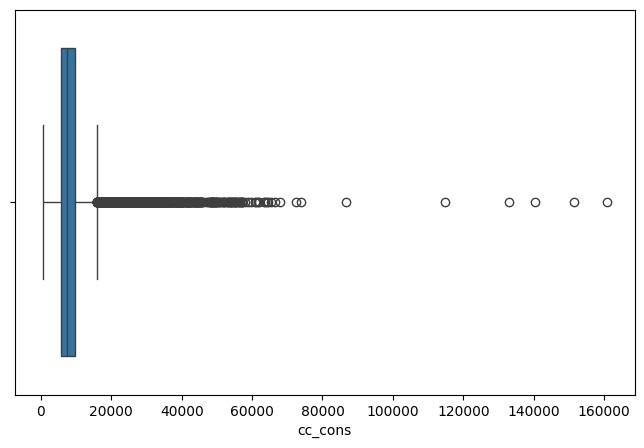

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["cc_cons"])

plt.show()

##### Understanding the target variable

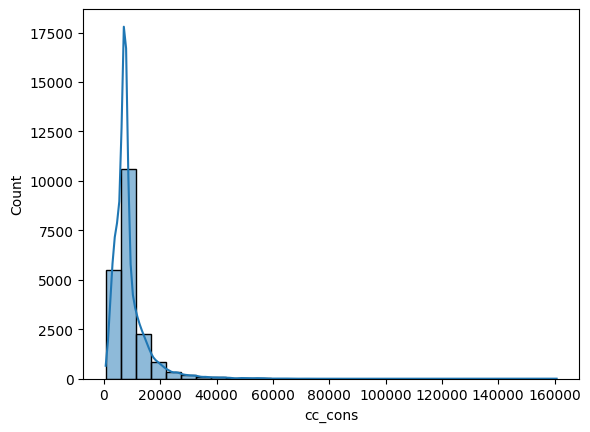

In [19]:
sns.histplot(
    df["cc_cons"],
    bins=30,
    kde=True
)

plt.show()

##### Here we do the corelation analysis that tells us that which factors affects spending more 

In [21]:
corr = df.corr(
    numeric_only=True
)
corr

,ID,age,Emp_Tenure_Years,Tenure_with_Bank,region_code,NetBanking_Flag,Avg_days_between_transaction,cc_cons_apr,dc_cons_apr,cc_cons_may,...,credit_amount_jun,credit_count_jun,debit_count_jun,max_credit_amount_jun,emi_active,cc_cons,Avg_CC_Spend,Avg_DC_Spend,Total_CC_Transactions,Total_DC_Transactions
ID,1.000000,-0.002185,0.006340,0.003843,0.003843,0.007011,0.013448,0.001836,-0.000093,-0.017831,...,-0.005036,0.009057,-0.002447,-0.014021,0.004497,-0.007326,-0.011225,-0.004089,-0.002164,0.003279
age,-0.002185,1.000000,0.200912,-0.001742,-0.001742,0.010439,0.003992,-0.001099,-0.000937,0.005360,...,0.005584,0.012914,0.001399,-0.004956,0.001246,-0.005306,0.001709,-0.001637,0.010656,-0.003633
Emp_Tenure_Years,0.006340,0.200912,1.000000,-0.003315,-0.003315,0.006272,0.006349,0.007394,0.009928,-0.001824,...,-0.003133,-0.000088,-0.000665,0.002695,-0.010143,-0.004620,-0.003413,0.011691,0.005171,0.006314
Tenure_with_Bank,0.003843,-0.001742,-0.003315,1.000000,1.000000,-0.000800,-0.007443,-0.003205,-0.010776,0.008934,...,0.002563,-0.006382,-0.003010,-0.010462,0.007814,-0.005300,-0.002005,-0.006136,0.006369,0.004203
region_code,0.003843,-0.001742,-0.003315,1.000000,1.000000,-0.000800,-0.007443,-0.003205,-0.010776,0.008934,...,0.002563,-0.006382,-0.003010,-0.010462,0.007814,-0.005300,-0.002005,-0.006136,0.006369,0.004203
NetBanking_Flag,0.007011,0.010439,0.006272,-0.000800,-0.000800,1.000000,0.005854,0.002396,-0.005654,-0.004209,...,0.003008,0.010303,0.012548,0.000893,0.006726,-0.005854,-0.002845,0.006595,0.002605,-0.016563
Avg_days_between_transaction,0.013448,0.003992,0.006349,-0.007443,-0.007443,0.005854,1.000000,0.007283,0.000745,0.006150,...,0.007982,0.006402,-0.001983,-0.000343,0.007043,0.000817,0.008467,0.005737,0.014400,-0.000604
cc_cons_apr,0.001836,-0.001099,0.007394,-0.003205,-0.003205,0.002396,0.007283,1.000000,-0.004596,0.010827,...,-0.004569,-0.004345,0.006793,0.006245,-0.003771,0.429972,0.618654,-0.003106,0.006577,0.004372
dc_cons_apr,-0.000093,-0.000937,0.009928,-0.010776,-0.010776,-0.005654,0.000745,-0.004596,1.000000,0.004041,...,-0.001275,-0.002405,-0.004368,-0.018256,-0.010985,0.250564,0.001401,0.545249,0.007058,0.005074
cc_cons_may,-0.017831,0.005360,-0.001824,0.008934,0.008934,-0.004209,0.006150,0.010827,0.004041,1.000000,...,0.004853,0.001713,-0.012480,0.031309,0.005989,0.461117,0.647507,-0.006387,-0.011621,-0.008471


In [22]:
corr["cc_cons"]\
.sort_values(ascending=False)

cc_cons                         1.000000
Avg_CC_Spend                    0.696605
cc_cons_may                     0.461117
cc_cons_apr                     0.429972
Avg_DC_Spend                    0.360144
dc_cons_may                     0.331815
cc_cons_jun                     0.306376
dc_cons_apr                     0.250564
debit_amount_may                0.011430
max_credit_amount_may           0.008218
credit_amount_apr               0.006765
investment_4                    0.006173
debit_count_jun                 0.005956
cc_count_jun                    0.003338
cc_count_may                    0.002949
investment_1                    0.002232
credit_amount_may               0.001912
Avg_days_between_transaction    0.000817
debit_amount_apr                0.000679
dc_cons_jun                     0.000105
dc_count_jun                    0.000104
Total_CC_Transactions          -0.000024
investment_2                   -0.000580
emi_active                     -0.000977
debit_count_apr 

##### Correlation heatmap

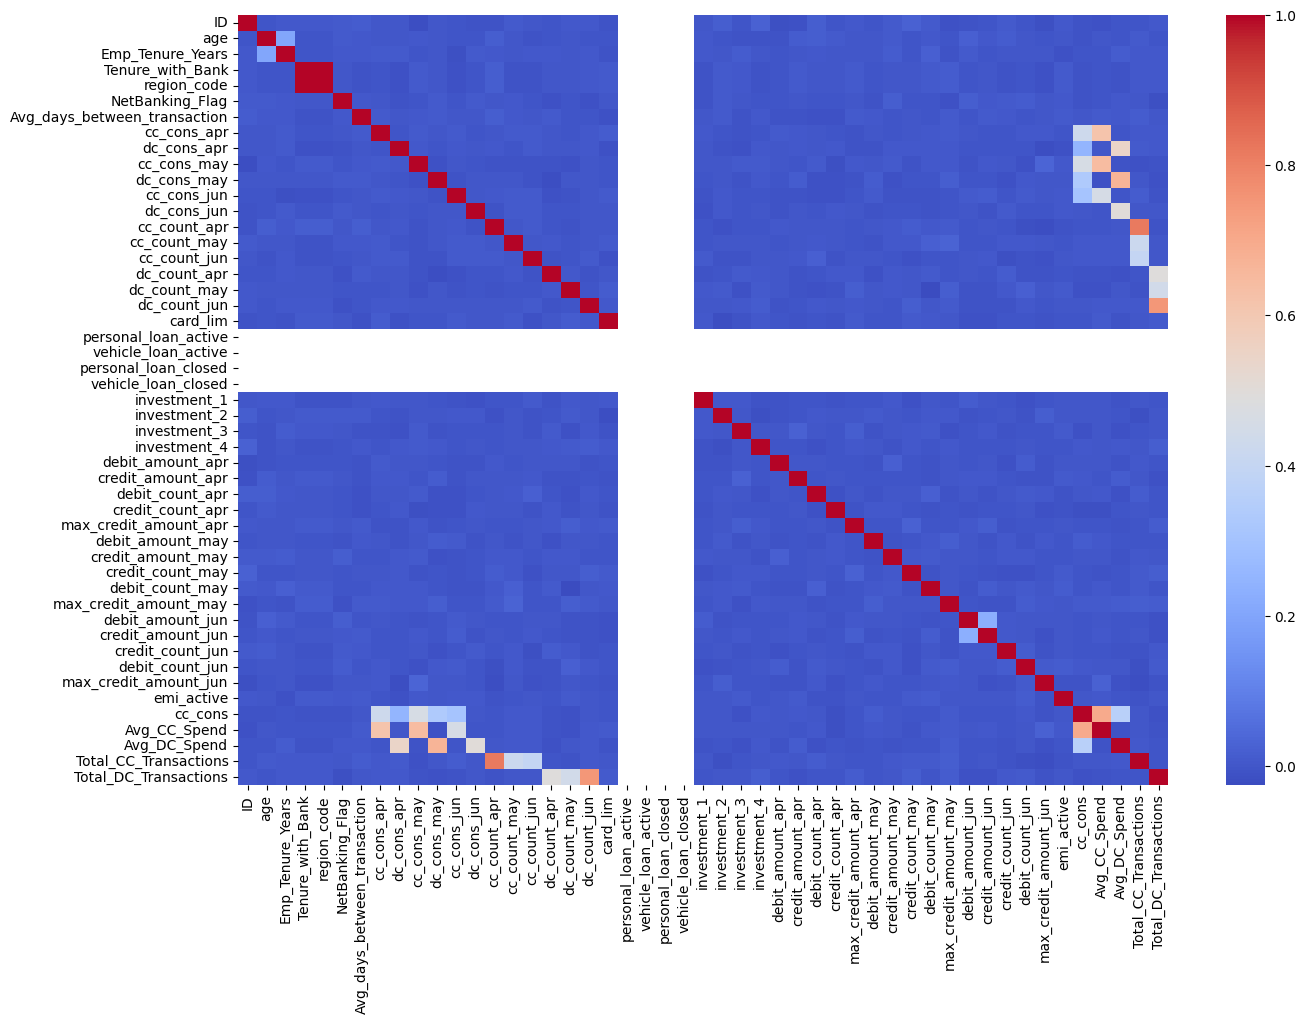

In [23]:
plt.figure(figsize=(15,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.show()

##### Income vs Consumption

In [24]:
df.groupby(
    "Income"
)["cc_cons"].mean()

Income
0         7408.604400
HIGH      8747.303780
LOW       8792.040900
MEDIUM    8933.829906
Name: cc_cons, dtype: float64

Gender vs Consumption

In [26]:
df.groupby(
    "gender"
)["cc_cons"].mean()

gender
0    7408.604400
F    8953.951513
M    8867.239038
Name: cc_cons, dtype: float64

##### Account_type vs Consumption

In [28]:
df.groupby(
    "account_type"
)["cc_cons"].mean()

account_type
0          7408.604400
current    8864.721716
saving     8957.600100
Name: cc_cons, dtype: float64

##### Region_code vs Consumption

In [30]:
df.groupby(
    "region_code"
)["cc_cons"].mean()

region_code
1     8790.062612
2     8984.585564
3     8966.679694
4     8826.108959
5     8749.311140
6     9096.355973
7     8909.513721
8     9108.793814
9     8736.039470
10    8618.285122
Name: cc_cons, dtype: float64

In [31]:
df.to_excel(
    "Credit_Consumption_Cleaned.xlsx",
    index=False
)